# Practice 2: Transfer Learning with Pretrained Architectures on CIFAR-10

## ResNet18 vs DenseNet121 — Frozen vs Fine-tuned

Load CIFAR-10, adapt ImageNet-pretrained ResNet18 and DenseNet121 for 10-class classification, train both frozen-backbone (feature extraction) and fine-tuned variants monitor with TensorBoard.

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Data Preparation | CIFAR-10 download, split persistence, ImageNet-compatible transforms, DataLoaders | `src/data/load_cifar10` |
| 3 | Model Architecture | Load pretrained ResNet18/DenseNet121, replace final layer, freeze/unfreeze | `torchvision.models` |
| 4 | Train Models | Training loop, TensorBoard logging | `src/training/` |
| 5 | Evaluate | Test-set accuracy, confusion matrices, per-class metrics | `src/eval/` |
| 6 | Compare & Report | Side-by-side comparison across all runs, summary table | — |
| 7 | Save Models | Save best checkpoints | — |

---


## Notebook Workflow

```mermaid
flowchart TD
    A["1. Import Libraries &amp; Detect Device"] --> B["2. Data Preparation \n(CIFAR-10 + Transforms)"]
    B --> C["3. Model Architecture \n(Pretrained ResNet18 / DenseNet121)"]
    C --> D["4. Train Models \n(Frozen vs Fine-tuned)"]
    D --> E["5. Evaluate \n(Test accuracy, per-class metrics)"]
    E --> F["6. Compare &amp; Report \n(Summary table across runs)"]
    F --> G["7. Save Models \n(Best checkpoints)"]

    subgraph Data["Data Pipeline"]
        B1["CIFAR-10 32x32"] --> B2["Resize(224) + Augment"]
        B2 --> B3["ImageNet Normalize"]
        B3 --> B4["train/val/test DataLoaders"]
    end

    subgraph Models["Architectures"]
        C1["ResNet18 \n(pretrained on ImageNet)"] --- C2["DenseNet121 \n(pretrained on ImageNet)"]
    end
```


## 1. Import Libraries

Set up environment, detect available device (MPS / CUDA / CPU), import project modules.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path
# Project root (absolute, immune to CWD changes)
PROJECT_ROOT = Path(os.path.abspath("..")).resolve()

from src.data.load_cifar10 import (
    get_cifar10_loaders,
    SPLIT_FILE,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

# Device detection
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device: {device}")


PyTorch version: 2.13.0
Torchvision version: 0.28.0
Using device: mps


## 2. Data Preparation — CIFAR-10

CIFAR-10: 10 classes, 32x32 RGB images, 50k train / 10k test. Pretrained models expect **224x224 ImageNet-normalized** input, so the transform pipeline resizes and normalizes accordingly.

**Transform pipeline (train):** `Resize(224)` -> `RandomHorizontalFlip()` -> `RandomCrop(224, padding=16)` -> `ToTensor()` -> `Normalize(ImageNet stats)`

**Train/val split:** 45k / 5k, generated once with `seed=42` and persisted to `data/processed/cifar10_split_seed42.json`. All phases share the same split.

**Batch size:** 64.  **num_workers:** 2.


Train: 45000  |  Val: 5000  |  Test: 10000
Split file: /Users/pickapu/Documents/PyCharmMiscProject/DeepLearning/Deeplearning_Course_UTH/data/processed/cifar10_split_seed42.json


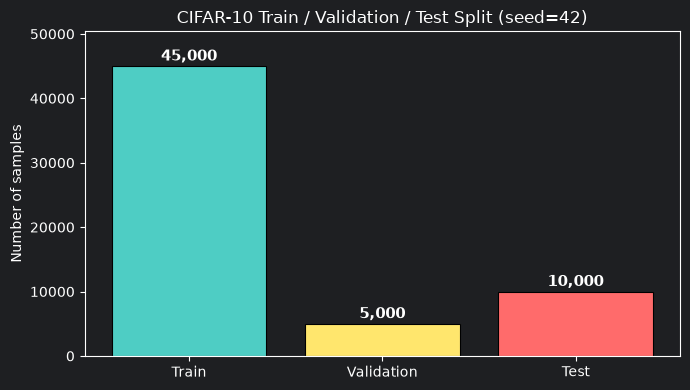

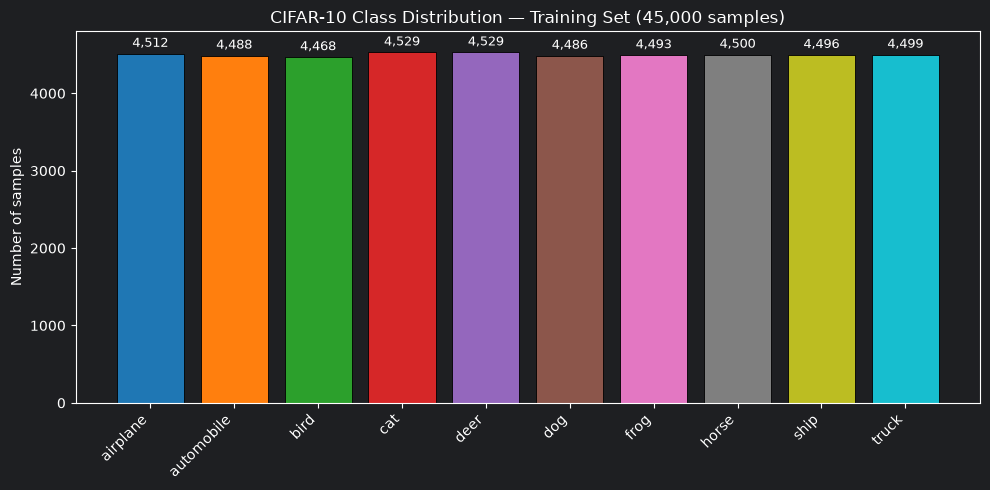


Batch shape: torch.Size([64, 3, 224, 224])  (batch, channels, H, W)
Pixel range after ImageNet normalization: -2.118 to 2.640
No NaN values: True


In [2]:
train_loader, val_loader, test_loader = get_cifar10_loaders(
    batch_size=64, num_workers=2
)

# ---- Split sizes ----
with open(SPLIT_FILE) as f:
    split = json.load(f)

n_train = len(split["train_indices"])
n_val   = len(split["val_indices"])
n_test  = len(split["test_indices"])

print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}")
print(f"Split file: {SPLIT_FILE}")

# ---- Train/val/test distribution bar plot ----
fig, ax = plt.subplots(figsize=(7, 4))
splits = ["Train", "Validation", "Test"]
counts = [n_train, n_val, n_test]
colors = ["#4ECDC4", "#FFE66D", "#FF6B6B"]
bars = ax.bar(splits, counts, color=colors, edgecolor="black", linewidth=0.8)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{count:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_title("CIFAR-10 Train / Validation / Test Split (seed=42)")
ax.set_ylim(0, max(counts) * 1.12)
plt.tight_layout()
plt.show()

# ---- Class distribution in the train set ----
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Count labels efficiently by iterating train indices
raw_train = torchvision.datasets.CIFAR10(
    root="../data/raw", train=True, transform=None, download=False
)
label_counter = Counter(
    raw_train[idx][1] for idx in split["train_indices"]
)

fig, ax = plt.subplots(figsize=(10, 5))
class_ids = range(10)
class_counts = [label_counter[i] for i in class_ids]
bar_colors = plt.cm.tab10(np.linspace(0, 1, 10))
bars = ax.bar(CIFAR10_CLASSES, class_counts, color=bar_colors,
              edgecolor="black", linewidth=0.6)
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of samples")
ax.set_title("CIFAR-10 Class Distribution — Training Set (45,000 samples)")
ax.set_ylim(0, max(class_counts) * 1.06)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- Quick shape sanity check ----
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}  (batch, channels, H, W)")
print(f"Pixel range after ImageNet normalization: "
      f"{images.min().item():.3f} to {images.max().item():.3f}")
print(f"No NaN values: {not torch.isnan(images).any()}")


## 3. Model Architecture

Load ImageNet-pretrained **ResNet18** and **DenseNet121** from torchvision, replace the final classification layer for 10 CIFAR-10 classes, and configure two freeze strategies per architecture:
- **Frozen (feature extraction):** only the new final layer is trainable
- **Fine-tune:** the last residual/dense block + final layer are trainable

The `weights=ResNet18_Weights.DEFAULT` API is used (torchvision 0.28.0, `pretrained=True` is deprecated).


In [3]:
from src.models.build_model import (
    build_resnet18, build_densenet121,
    count_trainable_params, count_all_params,
)

# --- Build all four variants ---
rn_frozen  = build_resnet18(num_classes=10, mode="frozen", device=device)
rn_finetune = build_resnet18(num_classes=10, mode="finetune", device=device)
dn_frozen  = build_densenet121(num_classes=10, mode="frozen", device=device)
dn_finetune = build_densenet121(num_classes=10, mode="finetune", device=device)

models_info = [
    ("ResNet18 (frozen)", rn_frozen, "fc(512, 10)"),
    ("ResNet18 (finetune)", rn_finetune, "fc(512, 10) + layer4"),
    ("DenseNet121 (frozen)", dn_frozen, "classifier(1024, 10)"),
    ("DenseNet121 (finetune)", dn_finetune, "classifier(1024, 10) + denseblock4"),
]

print(f"{"Model":30s} {"Trainable":>10s} {"Total":>10s}  Trainable layers")
print(f"{"-"*30} {"-"*10} {"-"*10}  {"-"*25}")
for name, model, layers in models_info:
    t = count_trainable_params(model)
    a = count_all_params(model)
    print(f"{name:30s} {t:>10,} {a:>10,}  {layers}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/pickapu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%
1.2%

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/pickapu/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100.0%


Model                           Trainable      Total  Trainable layers
------------------------------ ---------- ----------  -------------------------
ResNet18 (frozen)                   5,130 11,181,642  fc(512, 10)
ResNet18 (finetune)             8,398,858 11,181,642  fc(512, 10) + layer4
DenseNet121 (frozen)               10,250  6,964,106  classifier(1024, 10)
DenseNet121 (finetune)          2,170,378  6,964,106  classifier(1024, 10) + denseblock4


### 3.1 Forward pass sanity check

Verify all four variants produce `(batch, 10)` output.


In [4]:
dummy = torch.randn(4, 3, 224, 224).to(device)
for name, model, _ in models_info:
    model.eval()
    with torch.no_grad():
        out = model(dummy)
    print(f"  {name:30s} -> {out.shape}")
print("\u2713 All models pass forward check.")


  ResNet18 (frozen)              -> torch.Size([4, 10])
  ResNet18 (finetune)            -> torch.Size([4, 10])
  DenseNet121 (frozen)           -> torch.Size([4, 10])
  DenseNet121 (finetune)         -> torch.Size([4, 10])
✓ All models pass forward check.


## 4. Train Models

Train all four variants on CIFAR-10:
- **Frozen variants:** only the new final layer trains (LR=1e-3)
- **Fine-tune variants:** last block trains at 0.1 LR, final classifier at full LR (LR=1e-4) — discriminative fine-tuning per [TRAINING_INFO.md](../agent/phases/TRAINING_INFO.md)

AdamW optimizer, ``CrossEntropyLoss``.  Validation after every epoch.  Best checkpoint saved by val loss.  Logged to TensorBoard.

See ``notebooks/04_training.ipynb`` for detailed per-run output and plots.


In [ ]:
import os
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

from src.training.train_model import train_model
from src.data.config import TB_LOG_DIR, CKPT_DIR

# Create directories if they don't exist
os.makedirs(TB_LOG_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

NUM_EPOCHS = 10
BATCH_SIZE = 64
LR_FROZEN = 1e-3
LR_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4

# Build models (re-use the ones from Section 3, or rebuild)
from src.models.build_model import (
    build_resnet18, build_densenet121, count_trainable_params, count_all_params,
)

rn_frozen  = build_resnet18(num_classes=10, mode="frozen", device=device)
dn_frozen  = build_densenet121(num_classes=10, mode="frozen", device=device)
rn_finetune = build_resnet18(num_classes=10, mode="finetune", device=device)
dn_finetune = build_densenet121(num_classes=10, mode="finetune", device=device)

RUN_CONFIGS = [
    ("ResNet18-frozen",     rn_frozen,     LR_FROZEN,   "frozen"),
    ("DenseNet121-frozen",  dn_frozen,     LR_FROZEN,   "frozen"),
    ("ResNet18-finetune",   rn_finetune,   LR_FINETUNE, "finetune"),
    ("DenseNet121-finetune",dn_finetune,   LR_FINETUNE, "finetune"),
]

criterion = torch.nn.CrossEntropyLoss()
training_results = {}

for run_name, model, lr, mode in RUN_CONFIGS:
    print(f"\n=== Training: {run_name} ===")
    t = count_trainable_params(model)
    a = count_all_params(model)
    print(f"Params: {t:,} / {a:,} trainable | LR: {lr} | Epochs: {NUM_EPOCHS}")

    if mode == "finetune":
        backbone, head = [], []
        for n, p in model.named_parameters():
            if p.requires_grad:
                if "classifier" in n or n in ("fc.weight", "fc.bias"):
                    head.append(p)
                else:
                    backbone.append(p)
        optimizer = torch.optim.AdamW([
            {"params": backbone, "lr": lr * 0.1},
            {"params": head, "lr": lr},
        ], weight_decay=WEIGHT_DECAY)
    else:
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=WEIGHT_DECAY,
        )

    writer = SummaryWriter(log_dir=os.path.join(TB_LOG_DIR, run_name))
    res = train_model(model, train_loader, val_loader, criterion, optimizer,
                      device, num_epochs=NUM_EPOCHS, run_name=run_name,
                      writer=writer, save_dir=CKPT_DIR)
    writer.close()
    training_results[run_name] = res


=== Training: ResNet18-frozen ===
Params: 5,130 / 11,181,642 trainable | LR: 0.001 | Epochs: 10


NameError: name 'TB_LOG_DIR' is not defined

### 4.1 Results Summary


In [ ]:
print(f"{"Model":25s} {"Mode":10s} {"Best Val Acc":15s} {"Best Val Loss":15s} {"Epoch":8s}")
print("-" * 75)
for name, res in training_results.items():
    mode = "frozen" if "frozen" in name else "finetune"
    be = res["best_epoch"]
    bl = res["val_losses"][be - 1]
    ba = res["val_accs"][be - 1]
    print(f"{name:25s} {mode:10s} {ba:<15.2f}% {bl:<15.4f} {be:<8d}")


## 5. Evaluate

Evaluate all trained variants on the held-out CIFAR-10 test set.  Compute test accuracy, per-class accuracy, and a normalised confusion matrix for each model.

Checkpoints are loaded from ``experiments/checkpoints/<run_name>_best.pt``.  If checkpoints are not found, this section prints a message and skips.


In [ ]:
from pathlib import Path
from src.eval.evaluate_model import (
    evaluate, per_class_accuracy, load_checkpoint,
    format_comparison_table, CIFAR10_CLASSES,
)
from src.data.config import CKPT_DIR

variants = [
    ("ResNet18-frozen",     build_resnet18(num_classes=10, mode="frozen", device=device)),
    ("DenseNet121-frozen",  build_densenet121(num_classes=10, mode="frozen", device=device)),
    ("ResNet18-finetune",   build_resnet18(num_classes=10, mode="finetune", device=device)),
    ("DenseNet121-finetune",build_densenet121(num_classes=10, mode="finetune", device=device)),
]

eval_results = {}
for run_name, model in variants:
    ckpt_path = Path(CKPT_DIR) / f"{run_name}_best.pt"
    if not ckpt_path.exists():
        print(f"  ! Checkpoint not found: {ckpt_path}  (skipping)")
        continue
    model = load_checkpoint(model, str(ckpt_path), device)
    test_loss, test_acc = evaluate(model, test_loader, device)
    per_class, cm = per_class_accuracy(model, test_loader, device)
    mode = "frozen" if "frozen" in run_name else "finetune"
    eval_results[run_name] = {
        "mode": mode,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "per_class_acc": per_class,
        "confusion_matrix": cm.tolist(),
    }
    print(f"  {run_name:25s}  test_loss={test_loss:.4f}  test_acc={test_acc:.2f}%")
print(f"\nEvaluated {len(eval_results)} / {len(variants)} variants")

## 6. Compare & Report

Side-by-side comparison of all evaluated variants.  Includes per-class accuracy breakdown and a normalised confusion matrix heatmap.


In [ ]:
if not eval_results:
    print("No evaluation results — run Section 5 first.")
else:
    # Per-class accuracy grouped bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar chart
    ax = axes[0]
    x = np.arange(len(CIFAR10_CLASSES))
    width = 0.22
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for i, (name, res) in enumerate(eval_results.items()):
        offset = (i - 1.5) * width
        ax.bar(x + offset, res["per_class_acc"], width,
               label=name, color=colors[i], edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Per-Class Test Accuracy")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 105)

    # Comparison table
    ax2 = axes[1]
    ax2.axis("off")
    table_text = format_comparison_table(eval_results)
    ax2.text(0, 0.5, table_text, fontsize=9, family="monospace",
             verticalalignment="center", transform=ax2.transAxes)
    ax2.set_title("Comparison Table", fontsize=11)

    plt.tight_layout()
    plt.show()

    # Confusion matrix heatmaps
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for idx, (name, res) in enumerate(eval_results.items()):
        ax = axes.flatten()[idx]
        cm = np.array(res["confusion_matrix"])
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(CIFAR10_CLASSES)))
        ax.set_yticks(range(len(CIFAR10_CLASSES)))
        ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=7)
        ax.set_yticklabels(CIFAR10_CLASSES, fontsize=7)
        thresh = cm_norm.max() / 2
        for r in range(len(CIFAR10_CLASSES)):
            for c in range(len(CIFAR10_CLASSES)):
                ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=6,
                        color="white" if cm_norm[r, c] > thresh else "black")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(name, fontsize=10)
    # Hide unused subplots
    for idx in range(len(eval_results), 4):
        axes.flatten()[idx].axis("off")
    plt.tight_layout()
    plt.show()


### 6.1 Visualize Predictions

Display correctly classified and misclassified test-set examples for the best-performing variant.  Images are denormalised from ImageNet stats back to display range.


In [ ]:
# --- Helper: reverse ImageNet normalization for display ---
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

# Pick the best variant (highest test accuracy)
if eval_results:
    best_name = max(eval_results, key=lambda k: eval_results[k]["test_acc"])
    best_model = None
    for name, model in variants:
        if name == best_name:
            best_model = model
            break
    # Load the best checkpoint if available
    from src.data.config import CKPT_DIR
    best_ckpt = Path(CKPT_DIR) / f"{best_name}_best.pt"
    if best_ckpt.exists():
        from src.eval.evaluate_model import load_checkpoint
        best_model = load_checkpoint(best_model, str(best_ckpt), device)
    print(f"Best variant: {best_name}  (test acc={eval_results[best_name]["test_acc"]:.2f}%)")

    # Collect correct and incorrect predictions
    best_model.eval()
    correct_examples, incorrect_examples = [], []
    N_CORRECT = 8
    N_INCORRECT = 8

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = best_model(images)
            _, preds = outputs.max(1)

            for i in range(len(images)):
                img_denorm = denormalize(images[i].cpu(), IMAGENET_MEAN, IMAGENET_STD)
                if len(correct_examples) < N_CORRECT and preds[i] == labels[i]:
                    correct_examples.append((img_denorm, preds[i].item(), labels[i].item()))
                elif len(incorrect_examples) < N_INCORRECT and preds[i] != labels[i]:
                    incorrect_examples.append((img_denorm, preds[i].item(), labels[i].item()))
                if len(correct_examples) >= N_CORRECT and len(incorrect_examples) >= N_INCORRECT:
                    break
            if len(correct_examples) >= N_CORRECT and len(incorrect_examples) >= N_INCORRECT:
                break

    # --- Grid 1: Correct predictions ---
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for idx, (img, pred, true) in enumerate(correct_examples):
        ax = axes.flatten()[idx]
        img = torch.clamp(img, 0, 1)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(f"{CIFAR10_CLASSES[pred]}", fontsize=10, fontweight="bold")
        ax.axis("off")
    fig.suptitle(f"{best_name}: Correctly Classified Examples", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Grid 2: Incorrect predictions ---
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for idx, (img, pred, true) in enumerate(incorrect_examples):
        ax = axes.flatten()[idx]
        img = torch.clamp(img, 0, 1)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(f"Pred: {CIFAR10_CLASSES[pred]}\nTrue: {CIFAR10_CLASSES[true]}",
                     fontsize=8, color="red")
        ax.axis("off")
    fig.suptitle(f"{best_name}: Misclassified Examples", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"\u2713 Grids generated: {len(correct_examples)} correct, {len(incorrect_examples)} misclassified")
else:
    print("No evaluation results — run Section 5 first.")

## 7. Save Models & Results

Best checkpoints are already saved during training (``experiments/checkpoints/<run_name>_best.pt``).  Here we save the comparison table and metrics as JSON for the teacher report.


In [ ]:
if eval_results:
    os.makedirs(os.path.join(str(PROJECT_ROOT), "experiments", "results"), exist_ok=True)
    table = format_comparison_table(eval_results)
    (PROJECT_ROOT / "experiments" / "results" / "comparison_table.txt").write_text(table + "\n")
    summary = {
        name: {
            "mode": res["mode"],
            "test_loss": round(res["test_loss"], 4),
            "test_acc": round(res["test_acc"], 2),
            "per_class_acc": [round(v, 2) for v in res["per_class_acc"]],
        }
        for name, res in eval_results.items()
    }
    (PROJECT_ROOT / "experiments" / "results" / "test_metrics.json").write_text(
        json.dumps(summary, indent=2) + "\n"
    )
    print(f"Results saved to experiments/results/")
else:
    print("No evaluation results — nothing to save.")
